# Can you predict CDR status from **age alone**?

This notebook does something the CNN is not allowed to do: it throws away the brain scan
entirely and predicts **CDR-positive vs CDR-negative from a single number — the person's
age**.

Why bother? Because whatever accuracy age alone achieves is a **floor**. Any model that
also sees an MRI has to beat it before you can claim the images contributed anything. If a
CNN scores 0.65 on a cohort where age alone scores 0.61, the images bought you 0.04 — not
0.15 over chance.

The setup mirrors `step2-assign-groups.py`: pick an age band, balance the two classes, then
split into train and test. The only difference is that this notebook draws its own random
sample, so the exact subjects differ from the pipeline's.

> **This notebook is self-contained.** It does *not* read `config.yaml` — the settings below
> are its own, so you can explore any age band without touching the pipeline, and re-running
> this can never change what the CNN trains on. The knobs are `age_min` and `age_max` in the
> settings cell. To compare against the CNN, set them by hand to the band the pipeline used.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 120

NEG_COLOR, POS_COLOR = '#4C72B0', '#C44E52'
NEG_LABEL, POS_LABEL = 'CDR-negative', 'CDR-positive'

## Settings

Change `age_min` / `age_max` and re-run the notebook. A band where the two groups differ in
age will score well; a band where they overlap will not — that is the whole point.

*Where the data lives* is a separate matter: that comes from `DATA_RAW_PATH` in the gitignored
`.env` at the repository root — the same file the pipeline reads — so no path is hard-coded
here.

In [3]:
# --- experiment settings: this notebook's own, deliberately NOT read from config.yaml ---
age_min = 60            # inclusive
age_max = 80            # inclusive

# Split fractions matching the pipeline's `splits:` block, so the test set here is the same
# SIZE as the validation set step5 reports on -- which is what makes the two comparable.
# The leftover 15% is the pipeline's validation split; this notebook has no use for it and
# simply discards it.
train_fraction = 0.70   # same as splits.train
test_fraction = 0.15    # same as splits.test

seed = 42               # reproducible sampling and splitting

# --- where the OASIS spreadsheet lives ---
# This part IS machine-specific, so read it from the same gitignored .env the pipeline uses
# rather than hard-coding a path that only works on one computer.
repo_root = os.path.abspath('..') if os.path.isfile('../common.py') else os.path.abspath('.')
load_dotenv(os.path.join(repo_root, '.env'))

if 'DATA_RAW_PATH' not in os.environ:
    raise SystemExit('DATA_RAW_PATH is not set. Copy .env.example to .env at the repository '
                     'root and point it at your OASIS data (see readme.md).')

xlsx_path = os.path.join(os.path.expanduser(os.environ['DATA_RAW_PATH']),
                         'docs', 'oasis_cross-sectional.xlsx')

print(f'Age band: {age_min}-{age_max}')
print(f'Split: {train_fraction:.0%} train / {test_fraction:.0%} test '
      f'({1 - train_fraction - test_fraction:.0%} unused)   seed: {seed}')
print(f'Spreadsheet: {xlsx_path}')

Age band: 60-80
Split: 70% train / 15% test (15% unused)   seed: 42
Spreadsheet: /Users/emarti/Documents/washu/data/oasis/docs/oasis_cross-sectional.xlsx


In [4]:
raw = pd.read_excel(xlsx_path)

df = raw[raw['ID'].str.endswith('_MR1')].copy()   # drop the 20 repeat scans
df = df.dropna(subset=['CDR'])                    # young subjects were never assessed
df = df[['ID', 'M/F', 'Age', 'CDR']].reset_index(drop=True)
df['CDR_positive'] = df['CDR'] > 0

band = df[df['Age'].between(age_min, age_max)].copy()

print(f'{len(df)} labelled subjects -> {len(band)} in the {age_min}-{age_max} band')
print(f'  {NEG_LABEL}: {(~band["CDR_positive"]).sum()}    mean age {band.loc[~band["CDR_positive"], "Age"].mean():.1f}')
print(f'  {POS_LABEL}: {band["CDR_positive"].sum()}    mean age {band.loc[band["CDR_positive"], "Age"].mean():.1f}')
gap = band.loc[band['CDR_positive'], 'Age'].mean() - band.loc[~band['CDR_positive'], 'Age'].mean()
print(f'  age gap (positive - negative): {gap:+.1f} years')

235 labelled subjects -> 137 in the 60-80 band
  CDR-negative: 66    mean age 70.8
  CDR-positive: 71    mean age 73.3
  age gap (positive - negative): +2.5 years


## Balance the classes, then split 70 / 15

Balancing matters for honesty, not fairness: with equal numbers in each class, **chance is
exactly 0.50** and plain accuracy is directly interpretable. (This is the same reasoning
behind `cohort.balance: label` in the pipeline, and behind `introduction.md` §6.)

The split is **stratified** — train and test each keep the 50/50 mix — so the test score
cannot be inflated by a lucky draw of easy classes.

**Why 70 / 15 and not 70 / 30.** These are the pipeline's own fractions; the missing 15% is
its *validation* split, which this notebook has no use for and throws away. Keeping the same
fractions means the test set here has roughly the same **number of subjects** as the set
`step5-plot-training.py` reports on — so when we look at how much the score bounces around,
we are looking at the same amount of bounce the CNN's numbers have.

In [5]:
def balanced_split(band_df, train_fraction, test_fraction, rng):
    """Draw a class-balanced sample from band_df, then split it stratified.

    Mirrors step2-assign-groups.py: the cohort is capped at the size of the RARER class
    (so it comes out 50/50), and each class is split separately so train and test both
    keep that 50/50 mix.

    `rng` is passed in rather than created here, so calling this repeatedly with the same
    generator gives a DIFFERENT sample each time -- which is what the many-run cell needs.

    Returns (train, test, balanced). `balanced` is train + test + the discarded remainder.
    """
    neg = band_df[~band_df['CDR_positive']]
    pos = band_df[band_df['CDR_positive']]
    n_per_class = min(len(neg), len(pos))

    def take(group, n):
        keep = rng.choice(group.index.to_numpy(), size=n, replace=False)
        return group.loc[keep]

    balanced = pd.concat([take(neg, n_per_class), take(pos, n_per_class)])

    train_parts, test_parts = [], []
    for _, group in balanced.groupby('CDR_positive'):
        order = rng.permutation(group.index.to_numpy())
        n_train = int(round(train_fraction * len(order)))
        n_test = int(round(test_fraction * len(order)))
        train_parts.append(group.loc[order[:n_train]])
        test_parts.append(group.loc[order[n_train:n_train + n_test]])
        # anything past n_train + n_test is the pipeline's validation split -- dropped here

    return pd.concat(train_parts), pd.concat(test_parts), balanced


# Run it once, for the single-run walkthrough below.
rng = np.random.default_rng(seed)
train, test, balanced = balanced_split(band, train_fraction, test_fraction, rng)

print(f'balanced cohort: {len(balanced)}  ({len(balanced) // 2} per class)')
print(f'  train: {len(train):3d}  ({train["CDR_positive"].sum()} positive)')
print(f'  test:  {len(test):3d}  ({test["CDR_positive"].sum()} positive)')
print(f'  unused (the pipeline would call this validation): '
      f'{len(balanced) - len(train) - len(test)}')
print(f'  chance accuracy = {max(test["CDR_positive"].mean(), 1 - test["CDR_positive"].mean()):.3f}')

balanced cohort: 132  (66 per class)
  train:  92  (46 positive)
  test:   20  (10 positive)
  unused (the pipeline would call this validation): 20
  chance accuracy = 0.500


## Fit: one predictor, one yes/no answer

Logistic regression on age and nothing else. With a single predictor the fitted model
reduces to a rule you can say out loud — *"guess CDR-positive if the person is older than
X"* — and the cell below prints that X in years.

In [6]:
def fit_and_score(train, test):
    """Fit logistic regression on AGE ALONE and score it on both sets.

    Returns (model, metrics). `metrics` is a flat dict of scalars so that many runs can be
    stacked straight into a DataFrame.
    """
    X_train = train[['Age']].to_numpy(dtype=float)
    y_train = train['CDR_positive'].to_numpy(dtype=bool)
    X_test = test[['Age']].to_numpy(dtype=float)
    y_test = test['CDR_positive'].to_numpy(dtype=bool)

    model = LogisticRegression().fit(X_train, y_train)

    def score(X, y):
        pred = model.predict(X)
        prob = model.predict_proba(X)[:, 1]
        sens = (pred & y).sum() / y.sum()
        spec = ((~pred) & (~y)).sum() / (~y).sum()
        return {'accuracy': (pred == y).mean(), 'balanced_acc': (sens + spec) / 2,
                'sensitivity': sens, 'specificity': spec, 'auc': roc_auc_score(y, prob)}

    tr, te = score(X_train, y_train), score(X_test, y_test)
    coef = model.coef_[0, 0]

    metrics = {'train_n': len(y_train), 'test_n': len(y_test),
               # The decision boundary: P = 0.5 where intercept + coef * age = 0.
               'cutoff_age': -model.intercept_[0] / coef,
               'odds_ratio_per_year': float(np.exp(coef))}
    metrics.update({f'train_{k}': v for k, v in tr.items()})
    metrics.update({f'test_{k}': v for k, v in te.items()})
    return model, metrics


# Run it once.
model, metrics = fit_and_score(train, test)
cutoff_age = metrics['cutoff_age']

print(f'The fitted model is: predict {POS_LABEL} if age > {cutoff_age:.1f} years')
print(f'(odds of being {POS_LABEL} multiply by {metrics["odds_ratio_per_year"]:.3f} '
      f'per extra year)\n')

scores = pd.DataFrame(
    [{'set': s, 'n': metrics[f'{s}_n'],
      **{k: metrics[f'{s}_{k}'] for k in
         ['accuracy', 'balanced_acc', 'sensitivity', 'specificity', 'auc']}}
     for s in ('train', 'test')]).set_index('set')
print(scores.round(3))

The fitted model is: predict CDR-positive if age > 72.1 years
(odds of being CDR-positive multiply by 1.107 per extra year)

        n  accuracy  balanced_acc  sensitivity  specificity    auc
set                                                               
train  92     0.598         0.598        0.587        0.609  0.637
test   20     0.550         0.550        0.700        0.400  0.560


## What the rule looks like

Left: the age distribution of each class inside the band — the further apart these sit, the
more age alone can do. Right: the fitted probability curve, with each test subject drawn at
its own age, and the decision cutoff marked.

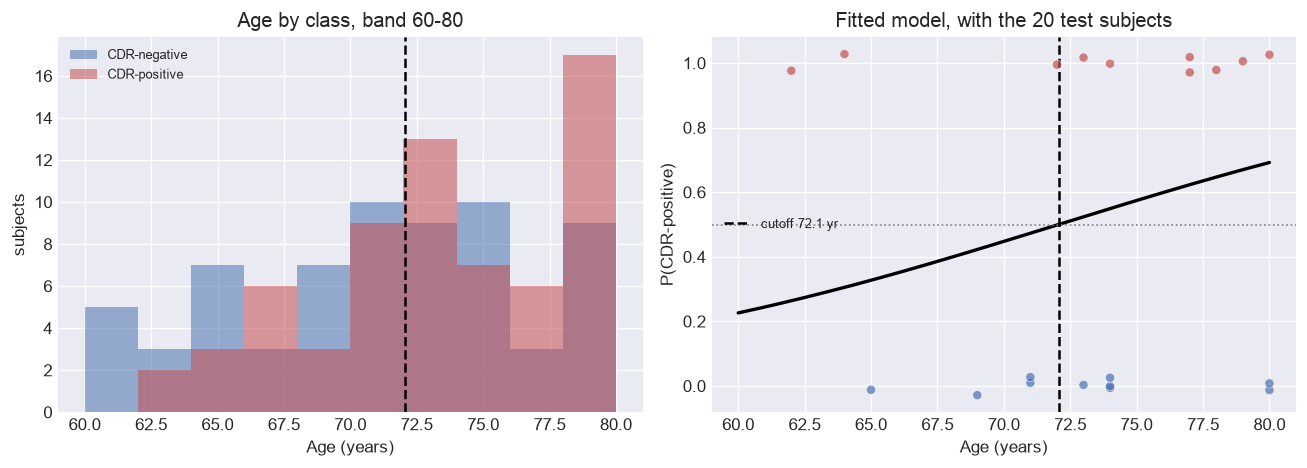

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

bins = np.arange(age_min, age_max + 2, 2)
for mask, colour, label in [(~balanced['CDR_positive'], NEG_COLOR, NEG_LABEL),
                            (balanced['CDR_positive'], POS_COLOR, POS_LABEL)]:
    ax1.hist(balanced.loc[mask, 'Age'], bins=bins, alpha=0.55, color=colour, label=label)
ax1.axvline(cutoff_age, color='black', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('subjects')
ax1.set_title(f'Age by class, band {age_min}-{age_max}')
ax1.legend(fontsize=8)

test_age = test['Age'].to_numpy(dtype=float)
test_y = test['CDR_positive'].to_numpy(dtype=bool)

grid = np.linspace(age_min, age_max, 200).reshape(-1, 1)
ax2.plot(grid, model.predict_proba(grid)[:, 1], color='black', linewidth=2)
ax2.axhline(0.5, color='0.5', linestyle=':', linewidth=1)
ax2.axvline(cutoff_age, color='black', linestyle='--', linewidth=1.5,
            label=f'cutoff {cutoff_age:.1f} yr')
jitter = rng.uniform(-0.03, 0.03, size=len(test_y))
ax2.scatter(test_age, test_y.astype(float) + jitter, s=30, alpha=0.7,
            c=[POS_COLOR if v else NEG_COLOR for v in test_y],
            edgecolor='white', linewidth=0.4, zorder=3)
ax2.set_xlabel('Age (years)')
ax2.set_ylabel(f'P({POS_LABEL})')
ax2.set_title(f'Fitted model, with the {len(test_y)} test subjects')
ax2.legend(fontsize=8, loc='center left')

fig.tight_layout()
plt.show()

1000 runs, band 60-80   (train n=92, test n=20)

                 mean     sd   p2.5  p97.5
train_auc       0.625  0.033  0.561  0.690
test_auc        0.634  0.117  0.395  0.850
train_accuracy  0.584  0.031  0.522  0.642
test_accuracy   0.584  0.102  0.400  0.750


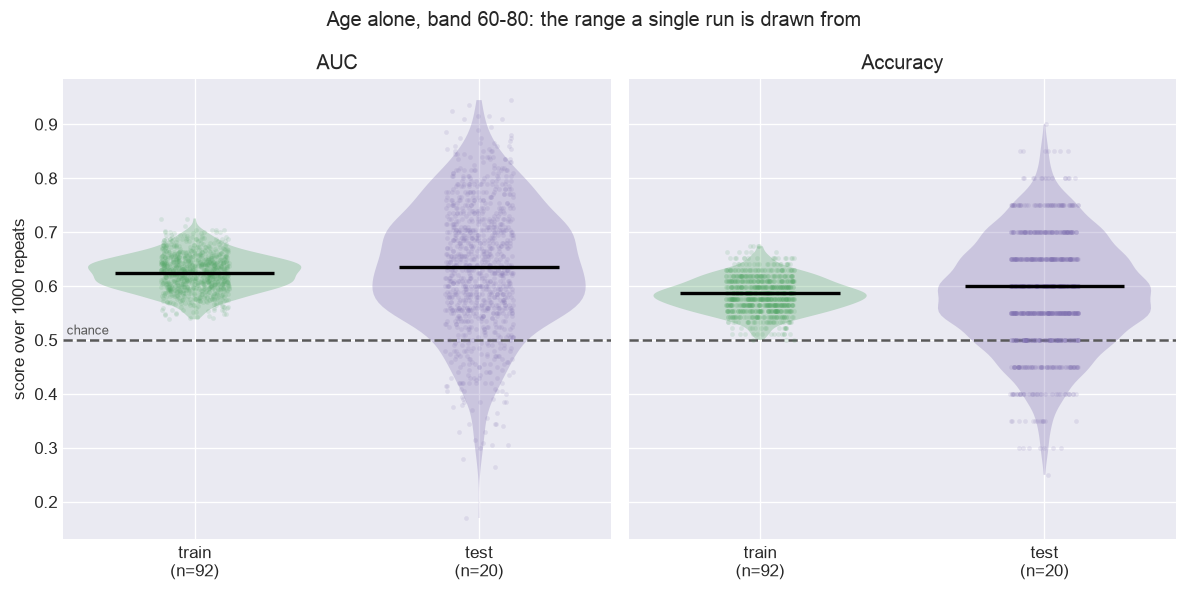

In [8]:
# Run many times
#
# Everything above is ONE run: one balanced draw, one split, one fit. The test set is only a
# few dozen people, so that single number carries a lot of luck. Here we repeat the whole
# procedure n_runs times -- a fresh balanced sample AND a fresh split each time -- and look
# at the spread. Takes roughly 10-20 seconds; lower n_runs if you are impatient.
n_runs = 1000

loop_rng = np.random.default_rng(seed)
records = []
for _ in range(n_runs):
    tr, te, _ = balanced_split(band, train_fraction, test_fraction, loop_rng)
    _, m = fit_and_score(tr, te)
    records.append(m)

runs = pd.DataFrame(records)

summary = pd.DataFrame({
    'mean': runs.mean(),
    'sd': runs.std(),
    'p2.5': runs.quantile(0.025),
    'p97.5': runs.quantile(0.975),
}).loc[['train_auc', 'test_auc', 'train_accuracy', 'test_accuracy']]
print(f'{n_runs} runs, band {age_min}-{age_max}   '
      f'(train n={runs["train_n"].iloc[0]}, test n={runs["test_n"].iloc[0]})\n')
print(summary.round(3))

# --- vertical dotplot + violin overlay, one panel per metric ---
TRAIN_COLOR, TEST_COLOR = '#55A868', '#8172B2'
panels = [('auc', 'AUC'), ('accuracy', 'Accuracy')]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, (key, title) in zip(axes, panels):
    series = [runs[f'train_{key}'].to_numpy(), runs[f'test_{key}'].to_numpy()]

    parts = ax.violinplot(series, positions=[1, 2], widths=0.75, showextrema=False)
    for body, colour in zip(parts['bodies'], [TRAIN_COLOR, TEST_COLOR]):
        body.set_facecolor(colour)
        body.set_alpha(0.30)

    for x, values, colour in [(1, series[0], TRAIN_COLOR), (2, series[1], TEST_COLOR)]:
        # 1000 points would saturate into a solid block, so keep them small and faint.
        jitter = loop_rng.uniform(-0.12, 0.12, size=len(values))
        ax.scatter(x + jitter, values, s=8, color=colour, alpha=0.15,
                   linewidth=0, zorder=3)
        ax.hlines(np.median(values), x - 0.28, x + 0.28, color='black',
                  linewidth=2, zorder=4)

    ax.axhline(0.5, color='0.35', linestyle='--', linewidth=1.5, zorder=1)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'train\n(n={runs["train_n"].iloc[0]})',
                        f'test\n(n={runs["test_n"].iloc[0]})'])
    ax.set_title(title)

axes[0].set_ylabel(f'score over {n_runs} repeats')
axes[0].text(0.55, 0.505, 'chance', fontsize=8, color='0.35', va='bottom')
fig.suptitle(f'Age alone, band {age_min}-{age_max}: the range a single run is drawn from')
fig.tight_layout()
plt.show()

## What to do with these numbers

**Read the distribution, not the point estimate.** The single run near the top of this
notebook produced one number; the figure above shows the range that number was drawn from.
Three things to look at:

- **Train sits above test.** That gap is *in-sample optimism* — the model was fitted on the
  training subjects, so scoring it on them flatters it. It is not a bug, and every model has
  it; this is just an unusually clean view of it.
- **Test is much wider than train.** With only a few dozen test subjects, luck in who landed
  in the test set moves the score by a lot. The training set is several times larger, so its
  score is correspondingly steadier.
- **Where the test distribution sits relative to 0.5.** If it straddles chance, age carries no
  usable signal in this band. If it sits clearly above, the age cue is real — and any model
  trained on this cohort can exploit it without ever looking at a brain.

**Then compare against the CNN — properly.** Take the balanced accuracy
`step5-plot-training.py` prints for designs 4a–4d on the *same* age band, and ask where it
falls in the **test** distribution above. The comparison only means something if the CNN's
number lands outside that spread:

- **CNN above the whole test distribution.** The images are contributing. This is the result
  you want.
- **CNN inside the test distribution.** You cannot distinguish the CNN from a rule that reads
  age off a spreadsheet. The network may have learned little more than "older people are more
  often CDR-positive" — something it can pick up from the scan, since brains visibly age.
- **CNN below.** A single number beats a neural network on a GPU. Worth knowing before anyone
  writes it up.

**The general lesson.** A confound is not a flaw in the model — it is a property of the
*dataset you assembled*. It is invisible in the training curves, invisible in the accuracy,
and invisible in Grad-CAM. The only way to find it is to ask what else, besides the thing you
care about, differs between your two groups — and then to test that thing on its own, as this
notebook does.

**Things to try**

1. Set `age_min`/`age_max` to a band where the two classes have almost the same mean age. What
   happens to the test distribution? What should that predict about the CNN?
2. Re-run the CNN (`bash process.sh`) on that same band and check whether your prediction held.
3. Raise `test_fraction` to 0.30 and re-run. The test distribution should narrow — same data,
   same signal, more test subjects. Does that change your view of any single reported score?
4. Swap `Age` for `nWBV` (see `jupyter/nWBV.ipynb`). Does brain volume still predict CDR status
   once you pick a band where age cannot?